In [603]:
import matplotlib.pyplot as plt
import numpy as np


###############################################################################
# PARSE ONLY SNP CLUSTERS
###############################################################################

def parse_clusters(filename):

    species_data = {}

    current_species = None
    in_cluster_section = False
    cluster_count = 0

    with open(filename, "r") as f:
        lines = [x.strip() for x in f if x.strip()]

    for line in lines:

        #######################################################################
        # CLUSTER LINES
        #######################################################################

        if in_cluster_section and line.startswith("# #"):

            # Example:
            # #1f77b4; -16,2,97; 0,27,474; ...

            pieces = [x.strip() for x in line[2:].split(";")]

            color = pieces[0]

            times  = []
            freqs  = []
            depths = []  # total depth at each timepoint

            for item in pieces[1:]:

                vals = item.split(",")

                if len(vals) != 3:
                    continue

                t, alt, depth = map(float, vals)

                if t < 0:
                    continue

                freq = np.nan if depth == 0 else alt / depth

                times.append(t)
                freqs.append(freq)
                depths.append(depth)  # store total depth

            species_data[current_species][color] = {
                "times":  np.array(times),
                "freqs":  np.array(freqs),
                "depths": np.array(depths)  # added
            }

            cluster_count -= 1
            if cluster_count == 0:
                in_cluster_section = False
            continue


        #######################################################################
        # SPECIES HEADER
        #######################################################################

        if (
            line.startswith("# ")
            and not any(
                k in line for k in [
                    "Clusters:",
                    "Private marker",
                    "Preserved",
                    "dN/dS",
                    "1D;",
                    "2D;",
                    "3D;",
                    "4D;"
                ]
            )
        ):

            current_species = line[2:].strip()

            if current_species not in species_data:
                species_data[current_species] = {}

            in_cluster_section = False
            continue

        #######################################################################
        # START OF CLUSTER SECTION
        #######################################################################

        if line.startswith("# Clusters:"):
            in_cluster_section = True
            cluster_count = float('inf')
            continue

        
    return species_data


###############################################################################
# LOAD FILES
###############################################################################

files = [
    "snps1.txt",
    "snps2.txt",
    "snps3.txt"
]

all_data = {}

for fn in files:

    dat = parse_clusters(fn)

    for species, clusters in dat.items():

        if not clusters:
            continue

        if species not in all_data:
            all_data[species] = {}

        all_data[species].update(clusters)


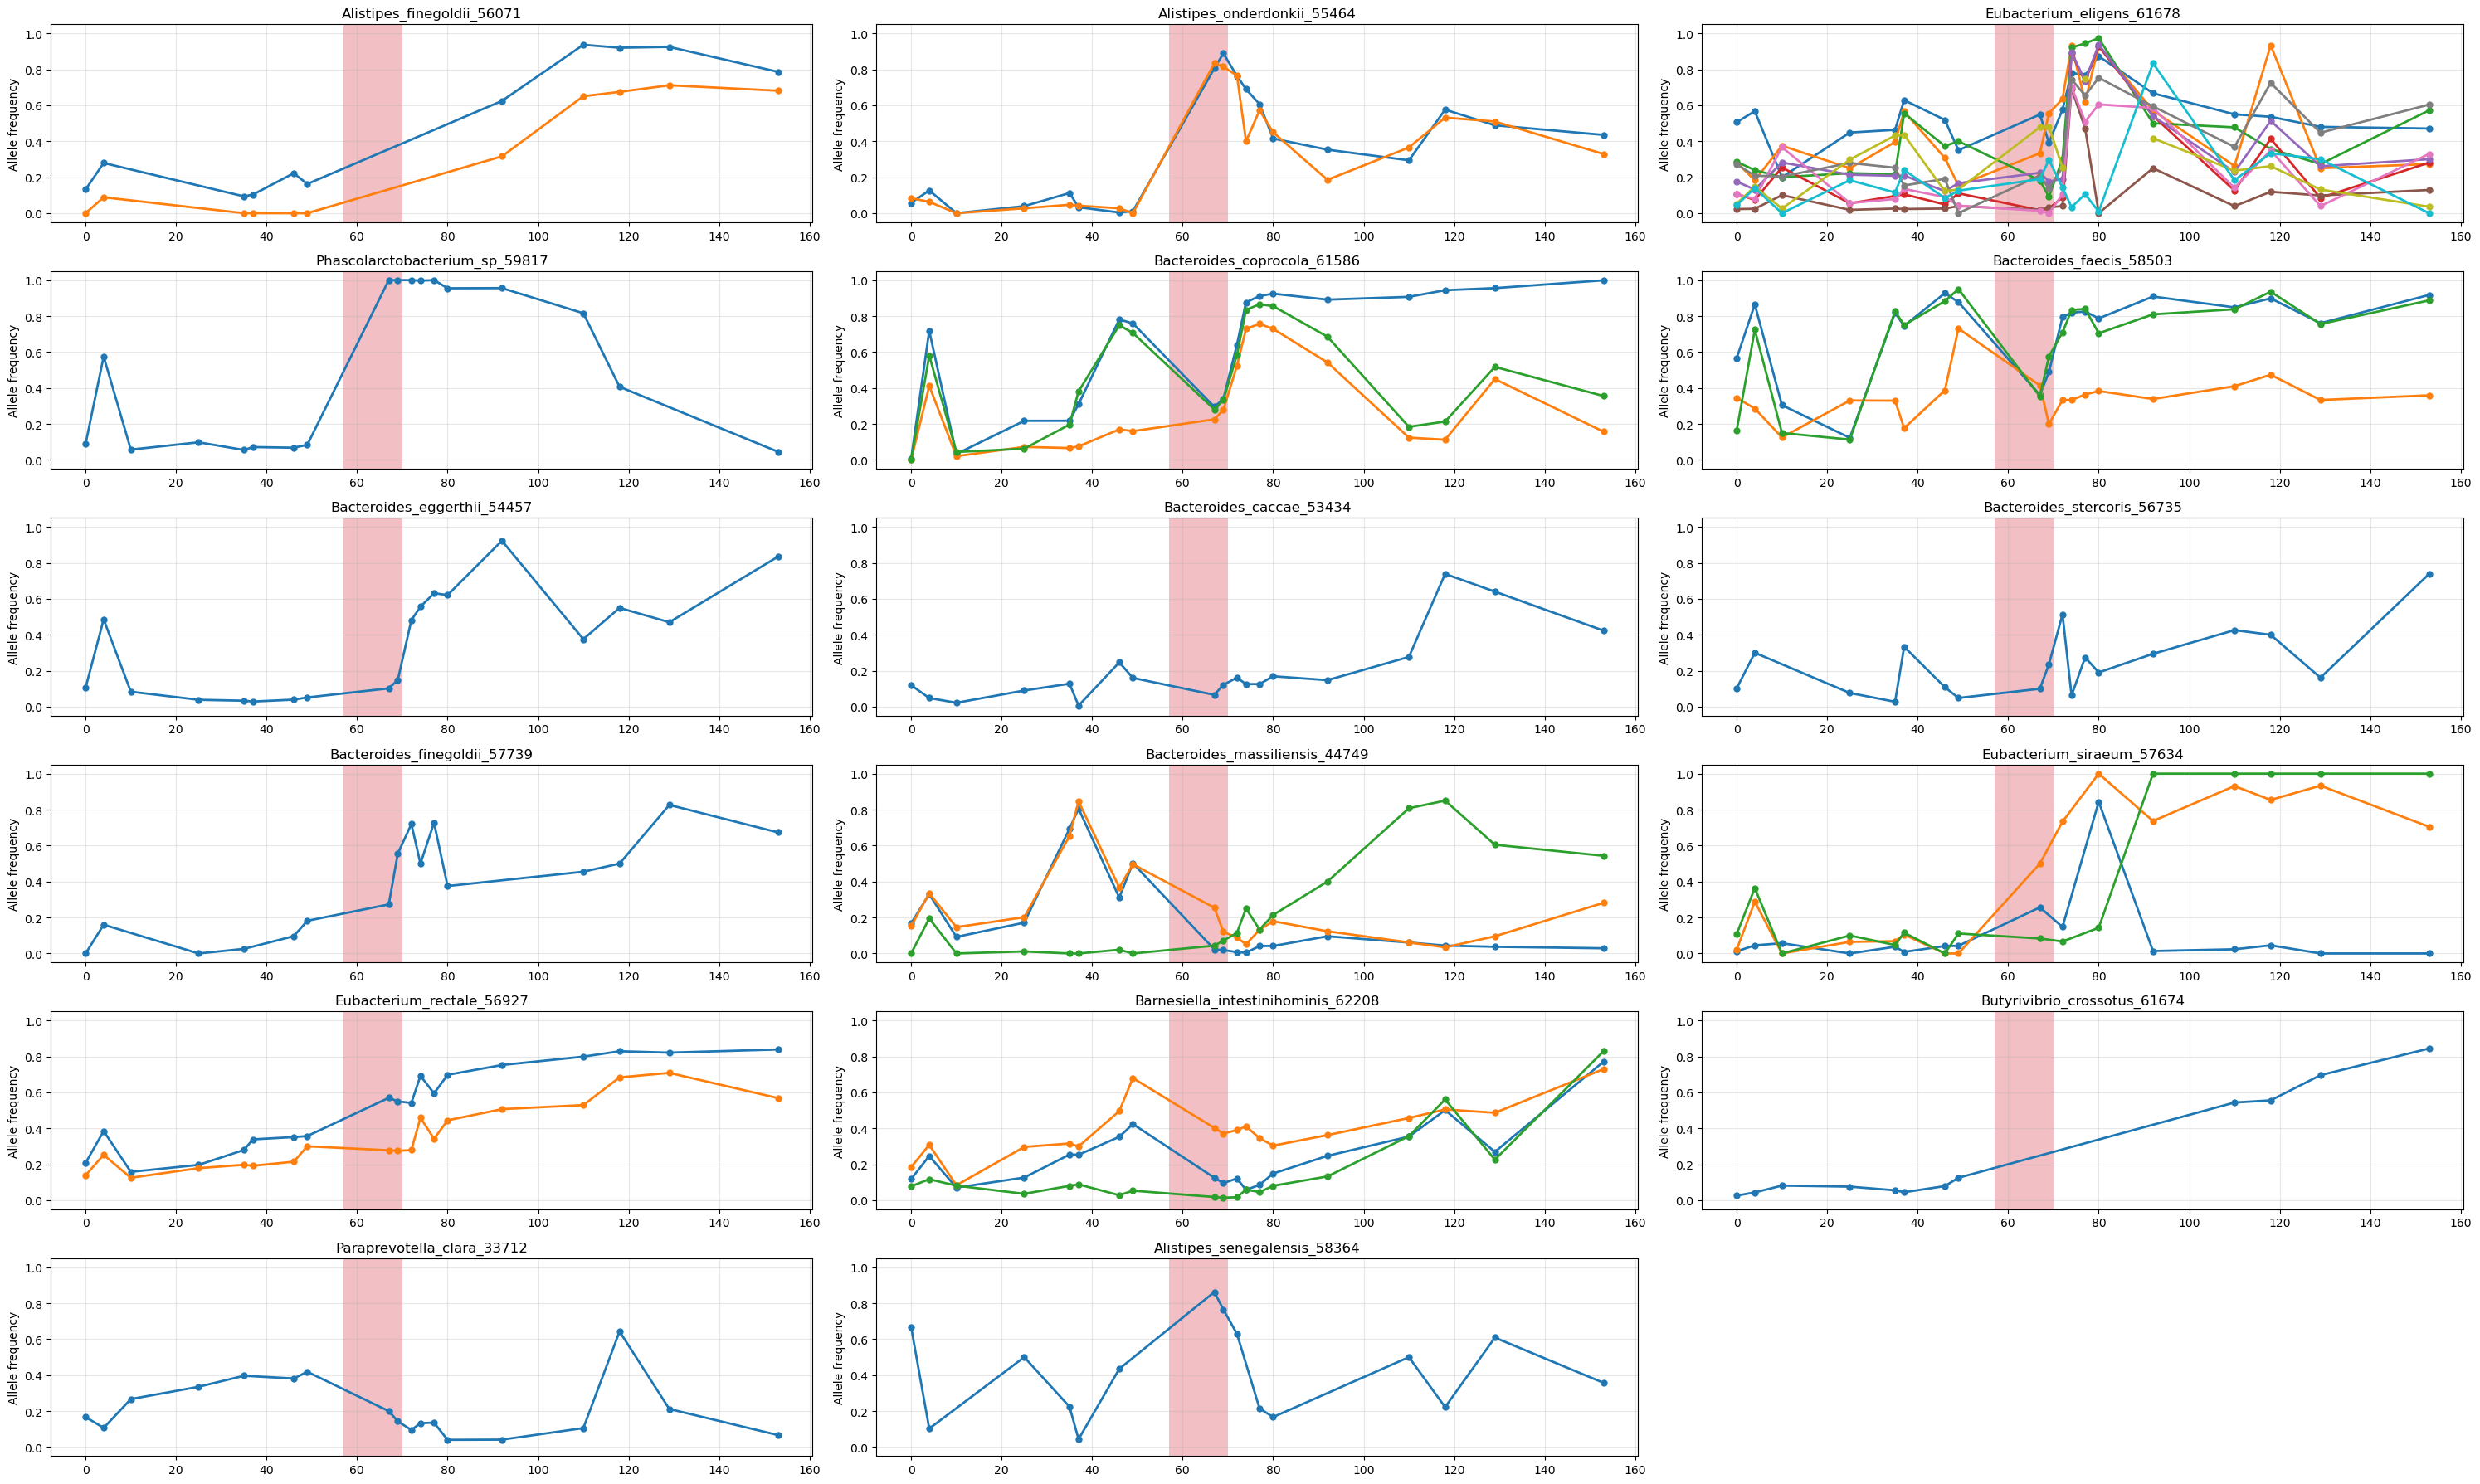

In [604]:
###############################################################################
# PLOT
###############################################################################

n_species = len(all_data)
disease_start = 35
antibiotic_start = 57
antibiotic_end = 70
antibiotic_color = '#e5818a'

fig, axes = plt.subplots(
    6,
    3,
    figsize=(30, 18),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for ax, (species, clusters) in zip(axes, all_data.items()):

    for color, vals in clusters.items():

        ax.plot(
            vals["times"],
            vals["freqs"],
            "-o",
            color=color,
            linewidth=2,
            markersize=5
        )

    ax.set_title(species)
    ax.set_ylabel("Allele frequency")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.fill_between([antibiotic_start, antibiotic_end], [-0.05, -0.05], [1.05, 1.05], color=antibiotic_color, alpha=0.5, linewidth=0)

axes[-1].set_xlabel("Time (Days)")

###############################################################################
# REMOVE UNUSED PANEL (18th)
###############################################################################

for j in range(len(all_data), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

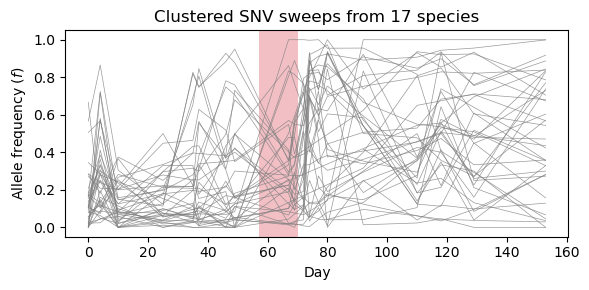

In [605]:
###############################################################################
# PLOT
###############################################################################

n_species = len(all_data)
disease_start = 35
antibiotic_start = 57
antibiotic_end = 70
antibiotic_color = '#e5818a'
plt.figure(figsize=(6, 3))
for species, clusters in all_data.items():

    for color, vals in clusters.items():

        plt.plot(
            vals["times"],
            vals["freqs"],
            "-o",
            color='gray',
            linewidth=0.5,
            markersize=0,
            alpha=0.8
        )

    plt.title('Clustered SNV sweeps from 17 species')
    plt.ylabel(r"Allele frequency ($f$)")
    plt.ylim(-0.05, 1.05)
    
plt.fill_between([antibiotic_start, antibiotic_end], [-0.05, -0.05], [1.05, 1.05], color=antibiotic_color, alpha=0.5, linewidth=0)

plt.xlabel("Day")

###############################################################################
# REMOVE UNUSED PANEL (18th)
###############################################################################

# for j in range(len(all_data), len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [606]:
###############################################################################
# HELPERS
###############################################################################

import statsmodels.api as sm
from scipy.stats import t as t_dist

# EPS = 0.01  # frequency floor for variance / logit stability
EPS = 0


def logit(p):
    return np.log(p / (1 - p))


def wls_linregress(f0, s, weights):
    """
    Weighted least-squares regression of s on f0 using statsmodels.

    Returns slope, intercept, HC3 robust SE of slope, weighted R², p-value.
    HC3 is used because the weights are estimated rather than known variance
    weights.
    """
    N = len(f0)
    if N < 3:  # need at least 3 observations for a 2-parameter regression
        return None

    y = np.asarray(s, dtype=float)
    X = sm.add_constant(np.asarray(f0, dtype=float))
    w = np.asarray(weights, dtype=float)

    model = sm.WLS(y, X, weights=w)
    res = model.fit(cov_type="HC3", use_t=True)
    # res = model.fit(use_t=True)

    b_int, m_slope = res.params
    slope_se = res.bse[1]
    r2 = res.rsquared

    # Two-sided p-value using the robust HC3 standard error.
    t_stat = m_slope / slope_se
    p_val = 2 * t_dist.sf(np.abs(t_stat), df=res.df_resid)

    return m_slope, b_int, slope_se, r2, p_val


def two_level_weights_by_cluster(w_raw_arr, cluster_ids):
    """
    Two-level normalisation: each cluster contributes equal total weight;
    within a cluster, weight proportional to w_raw.
    Output weights sum to 1.
    """
    unique_clusters = list(dict.fromkeys(cluster_ids))  # ordered unique
    C       = len(unique_clusters)
    w_final = np.zeros_like(w_raw_arr)
    for cid in unique_clusters:
        mask = np.array(cluster_ids) == cid
        w_c  = w_raw_arr[mask]
        if w_c.sum() > 0:
            w_final[mask] = w_c / (w_c.sum() * C)
    return w_final


def two_level_weights_by_species(w_raw_arr, species_arr, d0_arr=None):
    """
    Two-level normalisation: each species contributes equal total weight;
    within a species, weight proportional to w_raw.
    Output weights sum to 1.
    """
    unique_species = np.unique(species_arr)
    S       = len(unique_species)
    w_final = np.zeros_like(w_raw_arr)
    for sp in unique_species:
        mask = species_arr == sp
        w_c  = w_raw_arr[mask]
        if d0_arr is None:
            w_final[mask] = w_c / w_c.sum()
        else:
            w_final[mask] = w_c / d0_arr[mask].sum()  # weight inversely proportional to depth
            # w_final[mask] = d0_arr[mask] / d0_arr[mask].sum()  # weight proportional to w_raw within species
    w_final = w_final / w_final.sum()  # normalise to sum to 1
    return w_final


###############################################################################
# COMPUTE (f0, s) WITH TWO-LEVEL WEIGHTS  (level 1 = cluster, level 2 = depth)
###############################################################################

species_points = {}

for species, clusters in all_data.items():

    f0_all      = []
    s_all       = []
    w_raw_all   = []
    cluster_ids = []

    for color, vals in clusters.items():

        t = vals["times"]
        f = vals["freqs"]
        d = vals["depths"]

        for i in range(len(t) - 1):

            t0, t1 = t[i], t[i + 1]
            f0, f1 = f[i], f[i + 1]
            d0, d1 = d[i], d[i + 1]

            ###################################################################
            # Skip undefined logits
            ###################################################################

            if (
                np.isnan(f0)
                or np.isnan(f1)
                or f0 <= 0
                or f0 >= 1
                or f1 <= 0
                or f1 >= 1
            ):
                continue

            dt = t1 - t0

            if dt == 0:
                continue

            s = (logit(f1) - logit(f0)) / dt

            ###################################################################
            # Raw weight: 1 / Var(s)  ∝  1 / (Var(logit f0) + Var(logit f1))
            # Delta method: Var(logit f) ≈ 1 / (n · f(1-f))
            # so Var(s) ∝ f0c(1-f0c)/d0 + f1c(1-f1c)/d1  (ignoring 1/dt²)
            ###################################################################

            f0c   = np.clip(f0, EPS, 1 - EPS)
            f1c   = np.clip(f1, EPS, 1 - EPS)
            # w_raw = dt / (1 / f0c / (1 - f0c) / d0 + 1 / f1c / (1 - f1c) / d1)
            # w_raw = dt / (1 / f0c / (1 - f0c) / d0)
            # w_raw = 1.0 / (1 / d0 + 1 / d1)
            w_raw = d0

            f0_all.append(f0)
            s_all.append(s)
            w_raw_all.append(w_raw)
            cluster_ids.append(color)

    if not f0_all:
        continue

    f0_arr    = np.array(f0_all)
    s_arr     = np.array(s_all)
    w_raw_arr = np.array(w_raw_all, dtype=float)

    # Two-level normalisation: equal weight per cluster, within-cluster by depth
    w_final = two_level_weights_by_cluster(w_raw_arr, cluster_ids)

    species_points[species] = {
        "f0":      f0_arr,
        "s":       s_arr,
        "weights": w_final
    }


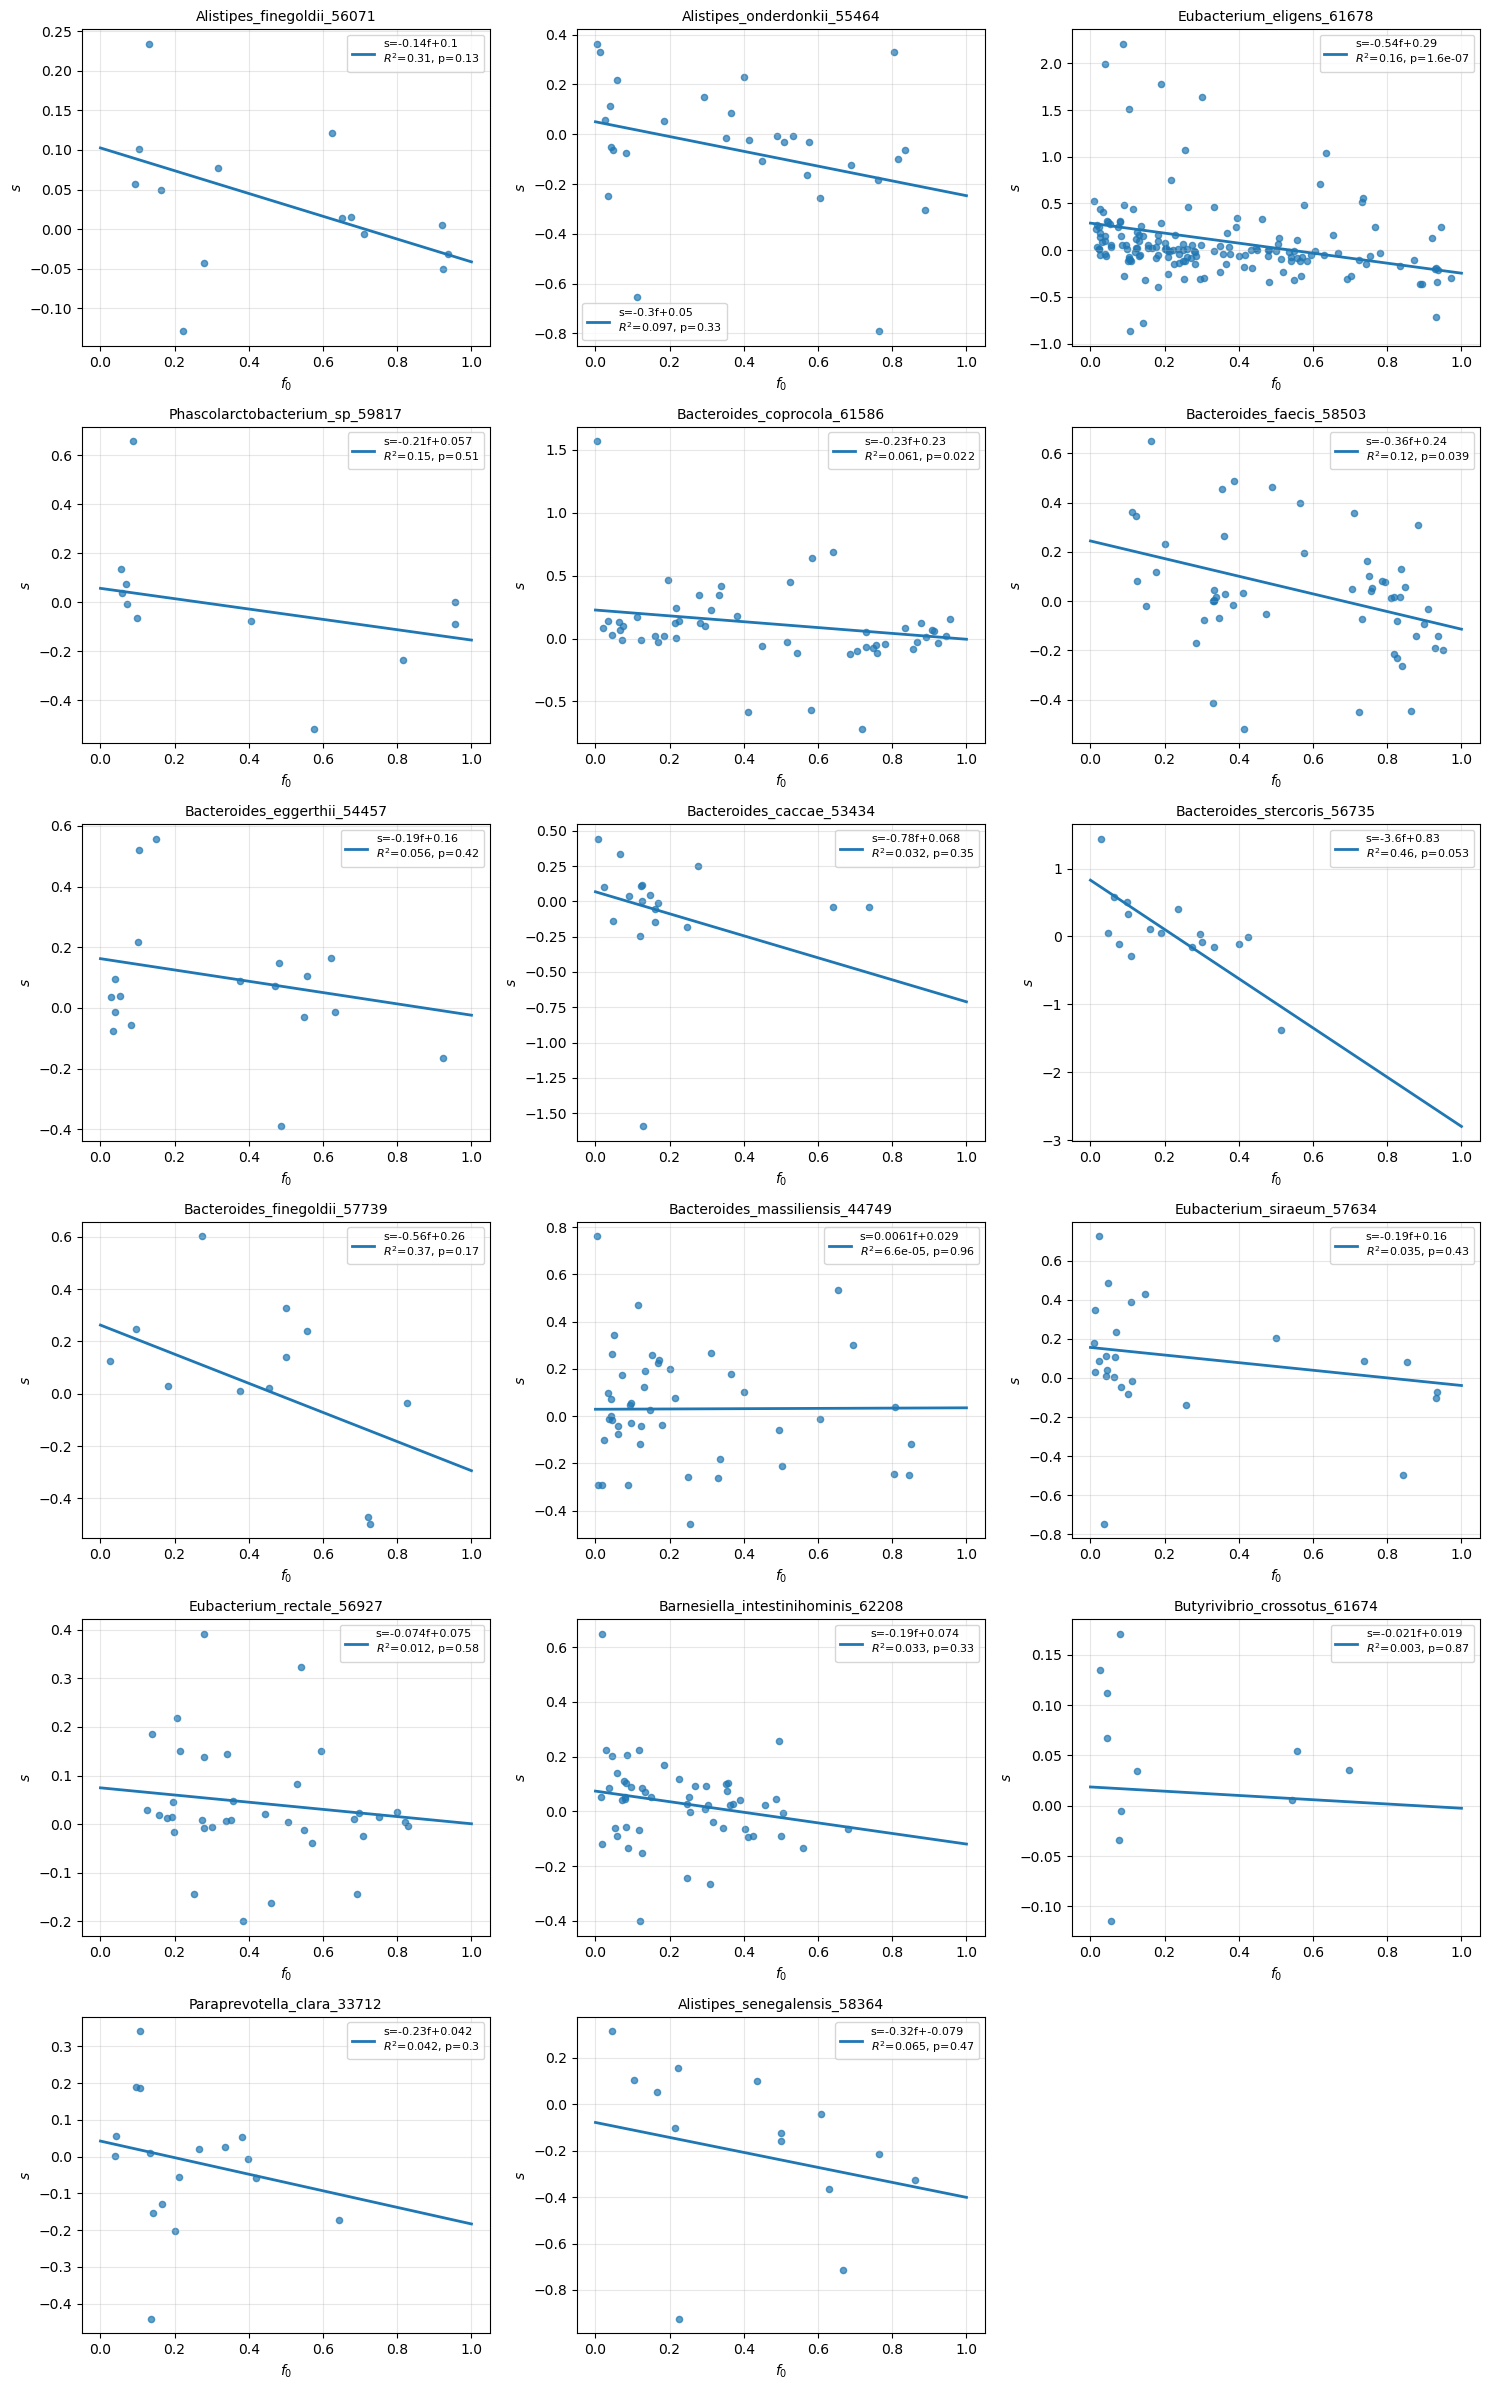

In [607]:
###############################################################################
# PLOT: 6 x 3 GRID  (WLS per species)
###############################################################################

fig, axes = plt.subplots(
    6,
    3,
    figsize=(15, 24),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for ax, (species, vals) in zip(axes, species_points.items()):

    f0      = vals["f0"]
    s       = vals["s"]
    weights = vals["weights"]

    ###########################################################################
    # Scatter — point size proportional to weight for visual clarity
    ###########################################################################

    ax.scatter(
        f0,
        s,
        alpha=0.7,
        s=20
    )

    ###########################################################################
    # statsmodels WLS linear regression with HC3 robust SE
    ###########################################################################

    result = wls_linregress(f0, s, weights)

    if result is not None:

        m, b, slope_se, r2, p = result

        xfit = np.linspace(0, 1, 200)
        yfit = m * xfit + b

        ax.plot(
            xfit,
            yfit,
            linewidth=2,
            label=(
                f"s={m:.2g}f+{b:.2g}\n"
                f"$R^2$={r2:.2g}, p={p:.2g}"
            )
        )

        ax.legend(fontsize=8)

    ax.set_title(species, fontsize=10)

    ax.set_xlabel(r"$f_0$")
    ax.set_ylabel(r"$s$")

    ax.grid(alpha=0.3)

###############################################################################
# REMOVE UNUSED PANEL (18th)
###############################################################################

for j in range(len(species_points), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


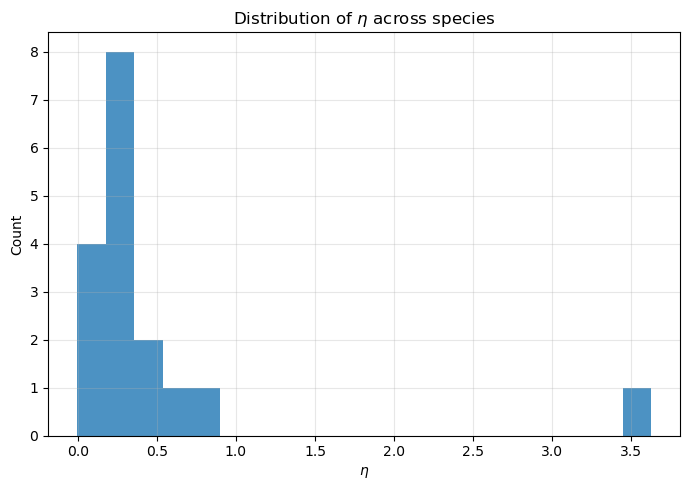

In [608]:
###############################################################################
# HISTOGRAM OF REGRESSION SLOPES ACROSS SPECIES  (statsmodels WLS)
###############################################################################

species_slopes = []

###############################################################################
# COMPUTE WLS SLOPE FOR EACH SPECIES
###############################################################################

for species, vals in species_points.items():

    f0      = np.array(vals["f0"])
    s       = np.array(vals["s"])
    weights = np.array(vals["weights"])

    result = wls_linregress(f0, s, weights)

    if result is not None:
        m, b, slope_se, r2, p = result
        species_slopes.append(m)

species_slopes = -np.array(species_slopes)

###############################################################################
# HISTOGRAM
###############################################################################

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    species_slopes,
    bins=20,
    alpha=0.8
)

###############################################################################
# MEAN LINE
###############################################################################

mean_slope = np.mean(species_slopes)

# ax.axvline(
#     mean_slope,
#     linestyle='--',
#     linewidth=2,
#     label=f"mean = {mean_slope:.3g}"
# )

# ax.legend()

ax.set_xlabel(r"$\eta$")
ax.set_ylabel("Count")

ax.set_title(r"Distribution of $\eta$ across species")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [609]:
###############################################################################
# COLLECT (f0, s) BY INITIAL TIME t0
# Also store species label and raw weight for two-level normalisation
###############################################################################

from collections import defaultdict

t0_points = defaultdict(lambda: {"f0": [], "s": [], "species": [], "w_raw": [], "d0": []})

for species, clusters in all_data.items():

    for color, vals in clusters.items():

        t = vals["times"]
        f = vals["freqs"]
        d = vals["depths"]

        for i in range(len(t) - 1):

            t0, t1 = t[i], t[i + 1]
            f0, f1 = f[i], f[i + 1]
            d0, d1 = d[i], d[i + 1]

            ###################################################################
            # Skip undefined logits
            ###################################################################

            if (
                np.isnan(f0)
                or np.isnan(f1)
                or f0 <= 0
                or f0 >= 1
                or f1 <= 0
                or f1 >= 1
            ):
                continue

            dt = t1 - t0

            if dt == 0:
                continue

            s = (logit(f1) - logit(f0)) / dt

            # Raw weight (same formula as species_points)
            f0c   = np.clip(f0, EPS, 1 - EPS)
            f1c   = np.clip(f1, EPS, 1 - EPS)
            # w_raw = dt / (1 / f0c / (1 - f0c) / d0 + 1 / f1c / (1 - f1c) / d1)
            # w_raw = dt / (1 / f0c / (1 - f0c) / d0)
            w_raw = d0
            # w_raw = 1.0 / (1 / d0 + 1 / d1)

            t0_points[t0]["f0"].append(f0)
            # t0_points[t0]["f0"].append((f0 + f1) / 2)  # use midpoint frequency for t0 point
            t0_points[t0]["s"].append(s)
            t0_points[t0]["species"].append(species)
            t0_points[t0]["w_raw"].append(w_raw)
            t0_points[t0]["d0"].append(d0)


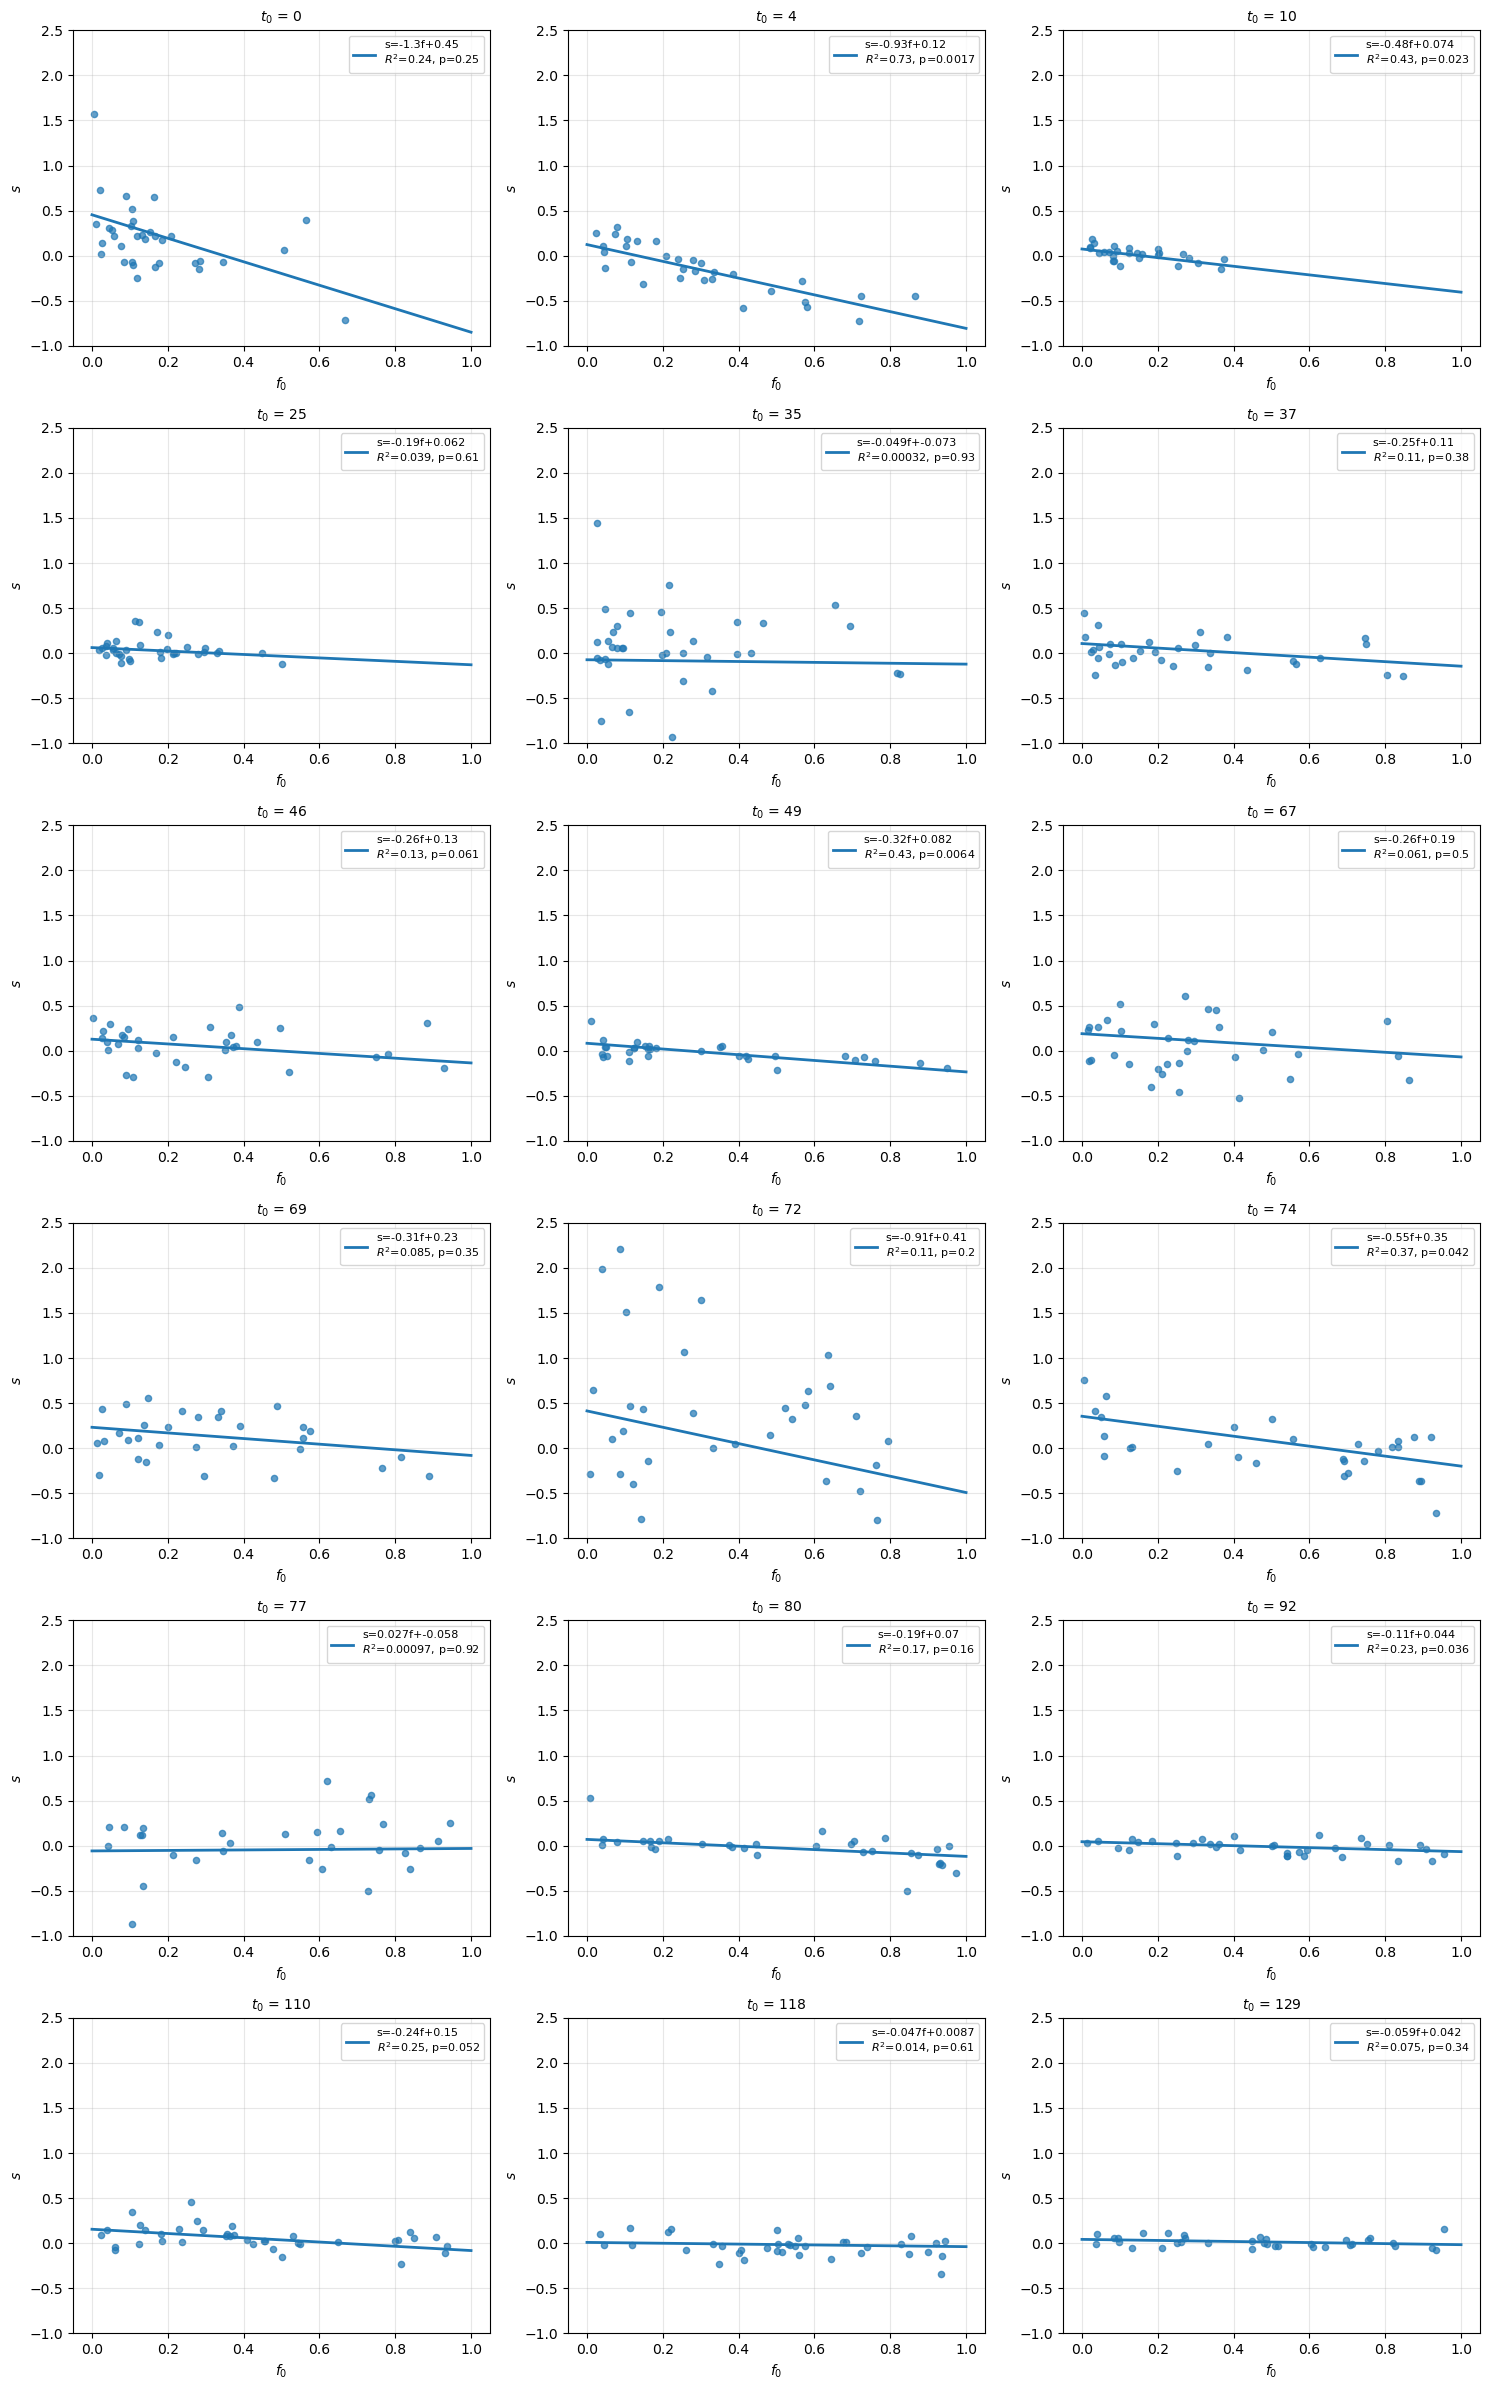

In [610]:
###############################################################################
# PLOT: per-t0 grid  (WLS, two-level weights by species)
###############################################################################

t0_values = sorted(t0_points.keys())

fig, axes = plt.subplots(
    6,
    3,
    figsize=(15, 24),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for ax, t0 in zip(axes, t0_values):

    f0         = np.array(t0_points[t0]["f0"])
    s          = np.array(t0_points[t0]["s"])
    species_arr = np.array(t0_points[t0]["species"])
    w_raw_arr  = np.array(t0_points[t0]["w_raw"], dtype=float)
    d0_arr      = np.array(t0_points[t0]["d0"], dtype=float)

    # Two-level: equal weight per species, within-species by depth
    weights = two_level_weights_by_species(w_raw_arr, species_arr, d0_arr)
    # weights = two_level_weights_by_species(w_raw_arr, species_arr)

    ###########################################################################
    # Scatter
    ###########################################################################

    ax.scatter(
        f0,
        s,
        alpha=0.7,
        s=20
    )

    ###########################################################################
    # statsmodels WLS linear regression with HC3 robust SE
    ###########################################################################

    result = wls_linregress(f0, s, weights)

    if result is not None:

        m, b, slope_se, r2, p = result

        xfit = np.linspace(0, 1, 200)
        yfit = m * xfit + b

        ax.plot(
            xfit,
            yfit,
            linewidth=2,
            label=(
                f"s={m:.2g}f+{b:.2g}\n"
                f"$R^2$={r2:.2g}, p={p:.2g}"
            )
        )

        ax.legend(fontsize=8)

    ax.set_title(f"$t_0$ = {t0:g}", fontsize=10)

    ax.set_xlabel(r"$f_0$")
    ax.set_ylabel(r"$s$")
    ax.set_ylim(-1, 2.5)

    ax.grid(alpha=0.3)

###############################################################################
# REMOVE UNUSED PANELS
###############################################################################

for j in range(len(t0_values), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


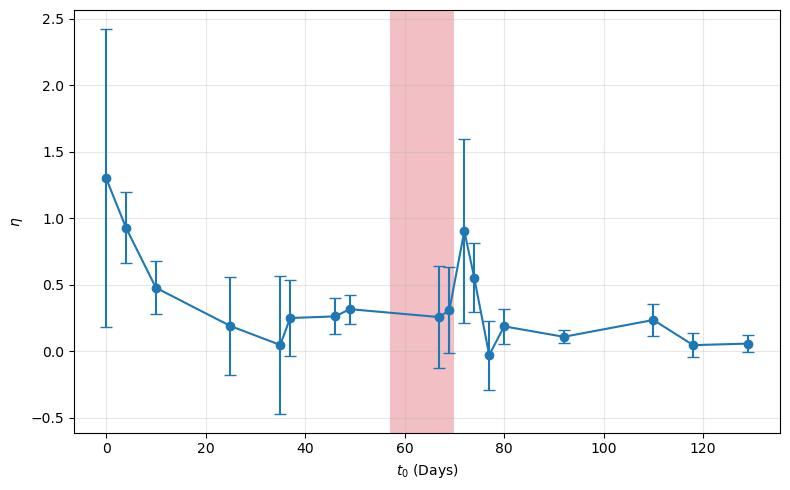

In [611]:
###############################################################################
# PLOT SLOPE VS TIME WITH ERROR BARS  (statsmodels WLS, HC3 robust SE)
###############################################################################

times      = []
slopes     = []
slope_errs = []
pvals      = []
r2s        = []

for t0 in sorted(t0_points.keys()):

    f0          = np.array(t0_points[t0]["f0"])
    s           = np.array(t0_points[t0]["s"])
    species_arr = np.array(t0_points[t0]["species"])
    w_raw_arr   = np.array(t0_points[t0]["w_raw"], dtype=float)
    d0_arr      = np.array(t0_points[t0]["d0"], dtype=float)

    # Two-level: equal weight per species, within-species by depth
    weights = two_level_weights_by_species(w_raw_arr, species_arr, d0_arr)
    # weights = two_level_weights_by_species(w_raw_arr, species_arr)

    result = wls_linregress(f0, s, weights)

    if result is None:
        continue

    m, b, slope_se, r2, p = result

    times.append(t0)
    slopes.append(m)
    slope_errs.append(slope_se)  # HC3 robust SE
    pvals.append(p)
    r2s.append(r2)

times      = np.array(times)
slopes     = np.array(slopes)
slope_errs = np.array(slope_errs)

###############################################################################
# PLOT
###############################################################################

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    times,
    -slopes,
    yerr=slope_errs,
    fmt='o-',
    capsize=4
)

ax.set_xlabel(r"$t_0$ (Days)")
ax.set_ylabel(r"$\eta$")
ax.fill_between(
    [antibiotic_start, antibiotic_end], 0, 1,
    transform=ax.get_xaxis_transform(),
    color=antibiotic_color, alpha=0.5, linewidth=0
)

# ax.set_title("Slope of $s$ vs $f_0$ over time")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


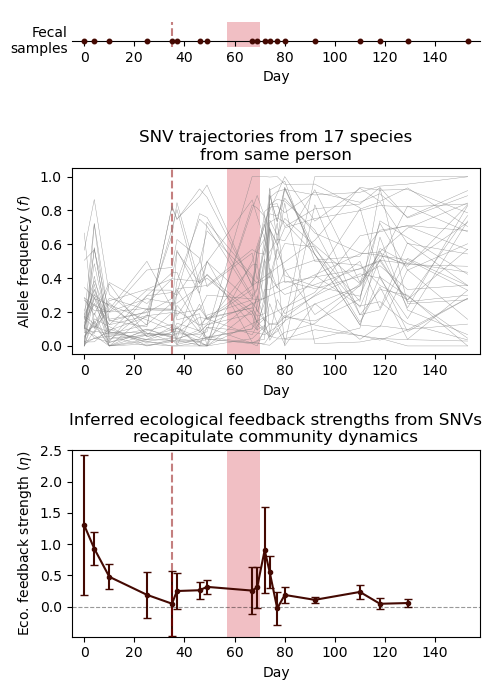

In [613]:
###############################################################################
# SUMMARY FIGURE: Timeline | SNP cluster example | Eta time series
# Three independent x-axes, visually aligned via shared xlim.
###############################################################################

# ── Change this to plot a different species in panel (2) ───────────────────
EXAMPLE_SPECIES = list(all_data.keys())[4]
# ────────────────────────────────────────────────────────────────────────────

# Collect all unique measurement time points across every species / cluster
_all_timepoints = set()
for _clusters in all_data.values():
    for _vals in _clusters.values():
        _all_timepoints.update(_vals["times"].tolist())
_all_timepoints = np.array(sorted(_all_timepoints))

# ── Figure layout: 3 rows, independent x-axes aligned via shared xlim ──────
fig, axes = plt.subplots(
    3, 1,
    figsize=(5, 7),
    sharex=False,
    gridspec_kw={"height_ratios": [1, 3, 3]}
)

def _shade_antibiotic(ax, ymin=0, ymax=1):
    ax.axvspan(
        antibiotic_start, antibiotic_end,
        ymin=ymin, ymax=ymax,
        color=antibiotic_color, alpha=0.5, linewidth=0
    )

# ── (1) Horizontal timeline ─────────────────────────────────────────────────
ax_tl = axes[0]
_shade_antibiotic(ax_tl, ymin=0.4, ymax=0.8)
ax_tl.scatter(
    _all_timepoints,
    np.zeros_like(_all_timepoints),
    marker=".",
    s=30,
    color="#440902",
    linewidths=1.5,
    zorder=10
)
ax_tl.set_yticks([])
ax_tl.set_ylim(-0.8, 0.8)
ax_tl.set_xlabel("Day")

# Move the x-axis spine to y=0 so tick marks sit on the data line
ax_tl.spines["bottom"].set_position(("data", 0))
ax_tl.spines[["left", "right", "top"]].set_visible(False)

# Place the y-label as text anchored at y=0 in data coords (on the axis line)
ax_tl.text(
    -0.01, 0,
    "Fecal\nsamples",
    transform=ax_tl.get_yaxis_transform(),   # x: axes fraction, y: data coords
    ha="right", va="center",
    # fontsize=9
)

ax_tl.axvline(disease_start, color="darkred", linewidth=1.5, linestyle="--", ymin=0.4, ymax=0.8, alpha=0.5)

# from matplotlib.patches import Patch
# ax_tl.legend(
#     handles=[Patch(color=antibiotic_color, alpha=0.5, label="Antibiotic treatment")],
#     loc="upper right",
#     fontsize=9,
#     frameon=False
# )

# # ── (2) SNP cluster time series for EXAMPLE_SPECIES ─────────────────────────
# ax_snp = axes[1]
# ax_snp_curves = []
# _shade_antibiotic(ax_snp)
# for _color, _vals in all_data[EXAMPLE_SPECIES].items():
#     curve, = ax_snp.plot(
#         _vals["times"],
#         _vals["freqs"],
#         "-o",
#         color=_color,
#         # linewidth=2,
#         markersize=3
#     )
#     ax_snp_curves.append(curve)
# ax_snp.set_ylabel(r"Allele frequency ($f$)")
# ax_snp.set_ylim(-0.05, 1.05)
# ax_snp.set_title('Example: Bacteroides coprocola')
# ax_snp.set_xlabel("Day")
# ax_snp.axvline(disease_start, color="darkred", linewidth=1.5, linestyle="--", alpha=0.5)
# ax_snp.grid(alpha=0.3)

# from matplotlib.legend_handler import HandlerTuple

# # Group them into one legend entry
# ax_snp.legend(
#     [tuple(ax_snp_curves)],          # tuple of handles → one entry
#     ["SNV clusters"],             # single label
#     handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
# )

# ── (2) SNP cluster time series for all species ─────────────────────────

ax_snp = axes[1]
_shade_antibiotic(ax_snp)

for species, clusters in all_data.items():

    for color, vals in clusters.items():

        ax_snp.plot(
            vals["times"],
            vals["freqs"],
            "-o",
            color='gray',
            linewidth=0.3,
            markersize=0,
            alpha=0.8,
            zorder=5
        )

ax_snp.set_title('SNV trajectories from 17 species\nfrom same person')
ax_snp.set_ylabel(r"Allele frequency ($f$)")
ax_snp.set_ylim(-0.05, 1.05)
ax_snp.axvline(disease_start, color="darkred", linewidth=1.5, linestyle="--", alpha=0.5)
ax_snp.set_xlabel("Day")

# ── (3) Eta time series ──────────────────────────────────────────────────────
ax_eta = axes[2]
_shade_antibiotic(ax_eta)
ax_eta.errorbar(
    times,
    -slopes,
    yerr=slope_errs,
    markersize=3,
    fmt="o-",
    capsize=3,
    color='#440902'
)
ax_eta.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax_eta.set_title("Inferred ecological feedback strengths from SNVs\nrecapitulate community dynamics")
ax_eta.set_ylabel(r"Eco. feedback strength ($\eta$)")
ax_eta.set_xlabel("Day")
ax_eta.set_ylim(-0.48, 2.5)
# ax_eta.set_yscale('symlog', linthresh=0.05)
ax_eta.axvline(disease_start, color="darkred", linewidth=1.5, linestyle="--", alpha=0.5)
# ax_eta.grid(alpha=0.3)

# ── Align all three x-axes to the same limits ───────────────────────────────
_x_min = _all_timepoints.min() - 5
_x_max = _all_timepoints.max() + 5
for ax in axes:
    ax.set_xlim(_x_min, _x_max)

plt.tight_layout()
plt.savefig('data_analysis.pdf')
plt.show()
